In [5]:
!pip install torch torchvision torchaudio


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [9]:
torch.manual_seed(42)

In [10]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [11]:
df = pd.read_csv("./fmnist_small.csv")

In [12]:
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,1,0,0,0,0,0,0,0,0,0,...,69,12,0,0,0,0,0,0,0,0
5996,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5997,8,0,0,0,0,0,0,0,0,0,...,39,47,2,0,0,29,0,0,0,0
5998,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Basic Graph

In [13]:
fruits = ["Apple", "banana", "Mango"]
for index, fruit in enumerate(fruits):
  print(index, fruit)

0 Apple
1 banana
2 Mango


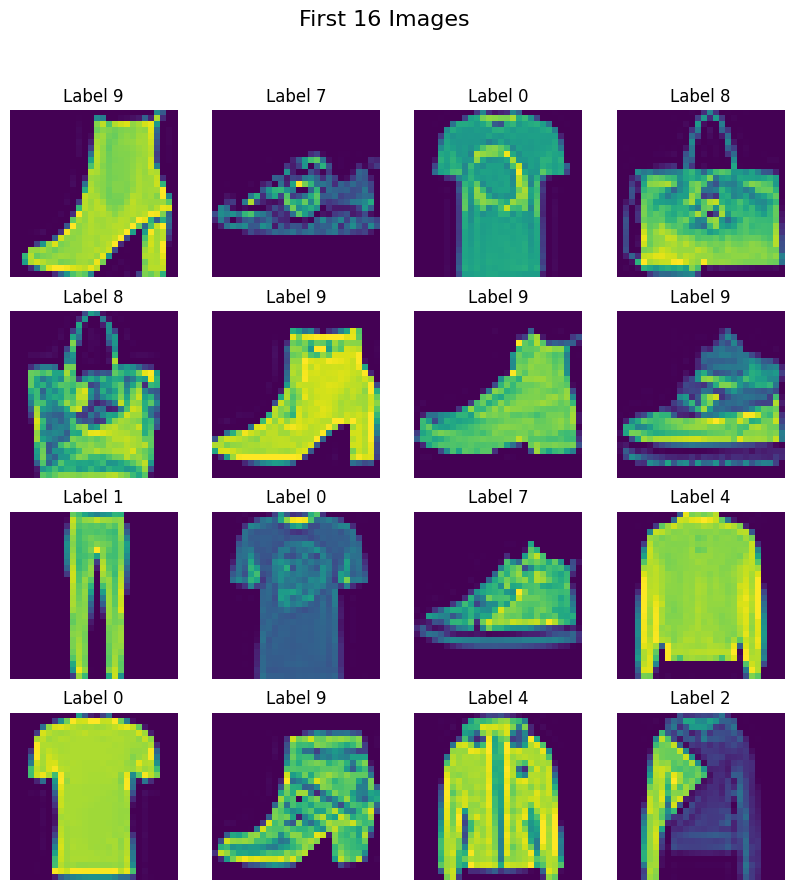

In [14]:
fig, axes = plt.subplots(4,4, figsize=(10,10))
fig.suptitle("First 16 Images", fontsize=16)
for i, ax in enumerate(axes.flat):
  img = df.iloc[i, 1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')

  ax.set_title(f"Label {df.iloc[i,0]}")

In [15]:
len(df.columns)

785

In [16]:
len(df['label'].unique())

10

In [17]:
len(df.iloc[:, 1:])

6000

In [18]:
# train test split
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
# Scaling the features
X_train = X_train / 255.0
X_test = X_test/255.0

### Custom Dataset

In [21]:
class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)
  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [22]:
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [23]:
len(train_dataset)

4800

In [24]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [25]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

### Define NN class

In [26]:
class MyNN(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )
  def forward(self, X):
    return self.model(X)

### Instatiate Model

In [27]:
epochs = 10
learning_rate = 0.1

In [28]:
model = MyNN(X_train.shape[1])

In [29]:
#loss function
criterion = nn.CrossEntropyLoss()

In [30]:
model.parameters()

<generator object Module.parameters at 0x000001B44A10EEA0>

In [31]:
#optimizers
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [32]:
len(train_loader)

150

### Training loop

In [33]:
for epoch in range(epochs):

  total_epoch_loss = 0

  for batch_features,batch_labels in train_loader:

    #forward pass
    output = model(batch_features)

    #calculate loss
    loss = criterion(output,batch_labels)

    #back pass
    optimizer.zero_grad()
    loss.backward()

    #update
    optimizer.step()

    # print(loss.item())
    total_epoch_loss = total_epoch_loss + loss.item()

avg_loss = total_epoch_loss / len(train_loader)

print(avg_loss)

0.39840923100709913


### Evaluation

In [34]:
temp = torch.tensor([
                    [0.2,0.1,0.7],
                    [0.2,0.1,0.7]
                    ])

_,predicted = torch.max(temp,1)
print(_)
print(predicted)

tensor([0.7000, 0.7000])
tensor([2, 2])


In [35]:
model.eval()

total = 0
correct = 0

with torch.no_grad():
  for batch_features,batch_labels in test_loader:
    outputs = model(batch_features)
    # print(f" outputs {outputs}")
    _,predicted = torch.max(outputs,1)
    # print(f"predicted {predicted}")

    #total
    total = total + batch_labels.shape[0]

    correct = correct + (predicted==batch_labels).sum().item()

print(correct/total)
# print(f"total number {total}")
# print(f"correct {correct}")

0.83
